# Rasch 1PL (Known Item Difficulties): Simulation, MLE, MCMC, and PPC

This notebook simulates a Rasch 1PL dataset with known item difficulties and estimates student abilities.

- 20 item difficulties: $b_j \sim \mathcal{N}(0,1)$
- 50 student abilities: $\theta_i \sim \mathcal{N}(0,2)$
- Response model: $Y_{ij} \sim \mathrm{Bernoulli}(\mathrm{logit}^{-1}(\theta_i-b_j))$

Inference uses known item difficulties. Generation densities are not used in the MLE step.

### What is included:

1. Cell 2 contains the setup commands (package install + cmdstan installation check), as requested.
2. Simulation of 20 item difficulties from Normal(0,1) and 50 student abilities from Normal(0,2).
3. Selection of two items with a large difficulty gap (easiest vs hardest), with characteristic curves along theta and student-level small-circle overlays of ability-probability points.
4. Response data generation from the Rasch model.
5. Histograms for proportion correct and total score.
6. Stan file generation inside the notebook as rasch_known_item_ability.stan for ability estimation with known item difficulties.
7. `optimize()` run for MLE-style estimation (no prior in optimize data).
8. Plot of estimated abilities vs true abilities.
9. Wright map using ability estimates and item-difficulty arrows under the theta axis.
10. MCMC sampling via cmdstanpy.
11. Violin plots of posterior samples for each ability parameter against true abilities.
12. Wright map using posterior means with item-difficulty arrows.
13. PPC plots (item-level proportion-correct check and total-score statistic) plus posterior predictive p-value.

In [1]:
# Commands requested for Cell 2
%pip install -q numpy pandas matplotlib seaborn scipy cmdstanpy arviz

import cmdstanpy

try:
    cmdstan_path = cmdstanpy.cmdstan_path()
    print(f'CmdStan is already installed at: {cmdstan_path}')
except Exception:
    cmdstanpy.install_cmdstan(cores=2, progress=True)

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import expit
from cmdstanpy import CmdStanModel

sns.set_theme(style='whitegrid')
np.random.seed(5101)

N = 150   # students
J = 20   # items

print(f'N={N}, J={J}')

N=150, J=20


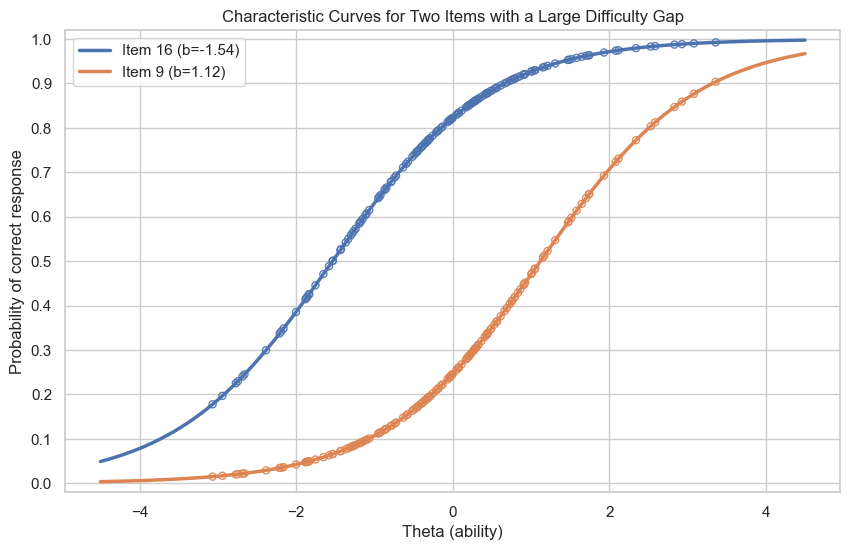

Easy item index: 16, b=-1.535
Hard item index: 9, b=1.120


In [3]:
# Generate item difficulties and true abilities
np.random.seed(5101) # For reproducibility

b_true = np.random.normal(loc=0.0, scale=1.0, size=J)
theta_true = np.random.normal(loc=0.0, scale=np.sqrt(2.0), size=N)

# Pick two items with a large gap: easiest and hardest
j_easy = int(np.argmin(b_true))
j_hard = int(np.argmax(b_true))

theta_grid = np.linspace(-4.5, 4.5, 300)
p_easy_grid = expit(theta_grid - b_true[j_easy])
p_hard_grid = expit(theta_grid - b_true[j_hard])

p_easy_students = expit(theta_true - b_true[j_easy])
p_hard_students = expit(theta_true - b_true[j_hard])

plt.figure(figsize=(10, 6))
plt.plot(theta_grid, p_easy_grid, lw=2.5, label=f'Item {j_easy+1} (b={b_true[j_easy]:.2f})')
plt.plot(theta_grid, p_hard_grid, lw=2.5, label=f'Item {j_hard+1} (b={b_true[j_hard]:.2f})')
plt.scatter(theta_true, p_easy_students, s=26, facecolors='none', edgecolors='C0', alpha=0.9)
plt.scatter(theta_true, p_hard_students, s=26, facecolors='none', edgecolors='C1', alpha=0.9)
plt.xlabel('Theta (ability)')
plt.ylabel('Probability of correct response')
plt.title('Characteristic Curves for Two Items with a Large Difficulty Gap')
plt.legend()
plt.ylim(-0.02, 1.02)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.show()

print(f'Easy item index: {j_easy+1}, b={b_true[j_easy]:.3f}')
print(f'Hard item index: {j_hard+1}, b={b_true[j_hard]:.3f}')

In [4]:
# Generate response matrix under Rasch model; resample if any student has all 0s or all 1s
# to keep finite MLEs in the no-prior optimize step.
max_tries = 200
for attempt in range(max_tries):
    p = expit(theta_true[:, None] - b_true[None, :])
    y = np.random.binomial(1, p, size=(N, J))
    row_sums = y.sum(axis=1)
    if np.all((row_sums > 0) & (row_sums < J)):
        break
else:
    raise RuntimeError('Could not avoid perfect scores; increase J or max_tries.')

prop_correct = y.mean(axis=1)
total_score = y.sum(axis=1)

print(f'Response matrix shape: {y.shape}')
print(f'Mean proportion correct: {prop_correct.mean():.3f}')
print(f'Mean total score: {total_score.mean():.3f}')
print(f'Max score: {total_score.max()}, Min score: {total_score.min()}')
print(f'Proportion of students with perfect scores: {(total_score == J).mean():.3f}')
print(f'Proportion of students with zero scores: {(total_score == 0).mean():.3f}')

Response matrix shape: (150, 20)
Mean proportion correct: 0.539
Mean total score: 10.787
Max score: 19, Min score: 1
Proportion of students with perfect scores: 0.000
Proportion of students with zero scores: 0.000


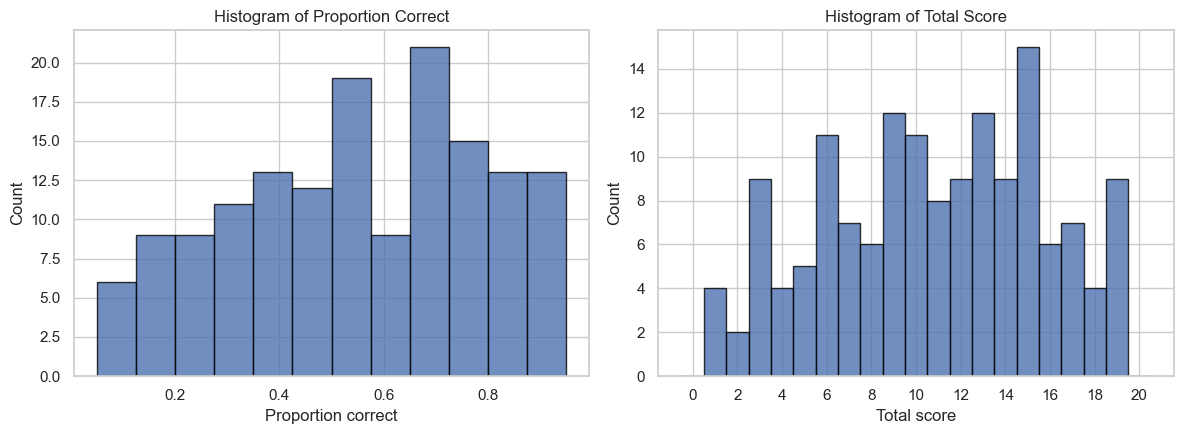

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(prop_correct, bins=12, edgecolor='black', alpha=0.8)
axes[0].set_title('Histogram of Proportion Correct')
axes[0].set_xlabel('Proportion correct')
axes[0].set_ylabel('Count')

axes[1].hist(total_score, bins=np.arange(-0.5, J + 1.5, 1), edgecolor='black', alpha=0.8)
axes[1].set_title('Histogram of Total Score')
axes[1].set_xlabel('Total score')
axes[1].set_xticks(np.arange(0, J + 1, 2))
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

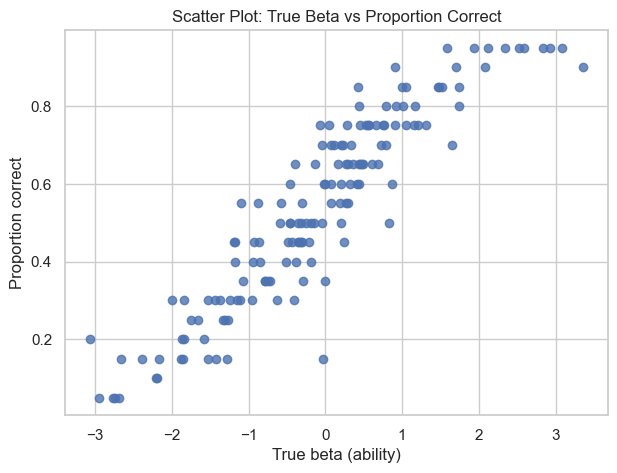

In [6]:
plt.figure(figsize=(7, 5))
plt.scatter(theta_true, prop_correct,  alpha=0.8)
plt.xlabel('True beta (ability)')
plt.ylabel('Proportion correct')
plt.title('Scatter Plot: True Beta vs Proportion Correct')
plt.show()

In [7]:
# Stan model: known item difficulties, optional weak prior for sampling.
stan_code = r'''
data {
  int<lower=1> N; // number of students
  int<lower=1> J; // number of items
  array[N, J] int<lower=0, upper=1> y; // response matrix
  vector[J] b; // known item difficulties
  int<lower=0, upper=1> use_prior; // flag to use prior
  real<lower=0> prior_sd; // standard deviation of prior
}
parameters {
  vector[N] theta; // student abilities
}
model {
  if (use_prior == 1)
    theta ~ normal(0, prior_sd);
  for (n in 1:N)
    y[n] ~ bernoulli_logit(theta[n] - b);
}
generated quantities {
  vector[N] log_lik;
  array[N, J] int y_rep;
  for (n in 1:N) {
    real lp = 0;
    for (j in 1:J) {
      lp += bernoulli_logit_lpmf(y[n, j] | theta[n] - b[j]);
      y_rep[n, j] = bernoulli_logit_rng(theta[n] - b[j]);
    }
    log_lik[n] = lp;
  }
}
'''

stan_path = 'rasch_known_item_ability.stan'
with open(stan_path, 'w', encoding='utf-8') as f:
    f.write(stan_code)

print(f'Wrote Stan file: {stan_path}')

Wrote Stan file: rasch_known_item_ability.stan


In [8]:
# cmdstanpy.install_cmdstan(compiler=True)

In [9]:
# Compile model and run optimize() for MLE (no prior)
model = CmdStanModel(stan_file=stan_path)

data_mle = {
    'N': N,
    'J': J,
    'y': y.tolist(),
    'b': b_true.tolist(),
    'use_prior': 0,
    'prior_sd': 5.0
}

fit_opt = model.optimize(data=data_mle, seed=5101, algorithm='lbfgs', iter=2000)
theta_mle = fit_opt.stan_variable('theta')

print('Optimization complete.')
print(f'Correlation(true, MLE) = {np.corrcoef(theta_true, theta_mle)[0,1]:.3f}')

17:23:40 - cmdstanpy - INFO - compiling stan file C:\Users\yongduek\Downloads\KOS-5101\irt\rasch_known_item_ability.stan to exe file C:\Users\yongduek\Downloads\KOS-5101\irt\rasch_known_item_ability.exe
17:23:55 - cmdstanpy - INFO - compiled model executable: C:\Users\yongduek\Downloads\KOS-5101\irt\rasch_known_item_ability.exe
17:23:55 - cmdstanpy - INFO - Chain [1] start processing
17:23:55 - cmdstanpy - INFO - Chain [1] done processing


Optimization complete.
Correlation(true, MLE) = 0.931


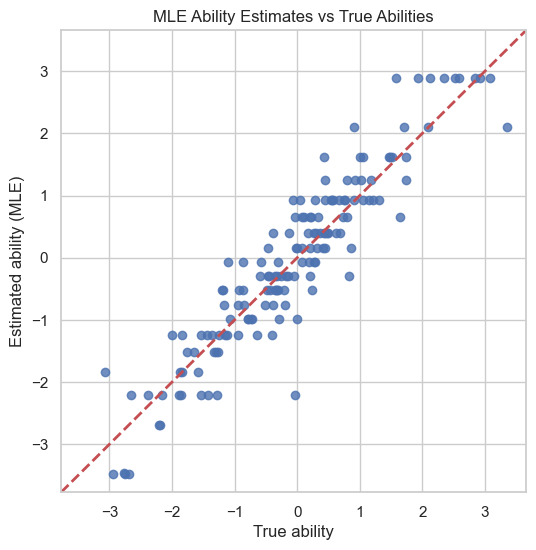

In [10]:
plt.figure(figsize=(6, 6))
plt.scatter(theta_true, theta_mle, alpha=0.8)
xy_min = min(theta_true.min(), theta_mle.min()) - 0.3
xy_max = max(theta_true.max(), theta_mle.max()) + 0.3
plt.plot([xy_min, xy_max], [xy_min, xy_max], 'r--', lw=2)
plt.xlim(xy_min, xy_max)
plt.ylim(xy_min, xy_max)
plt.xlabel('True ability')
plt.ylabel('Estimated ability (MLE)')
plt.title('MLE Ability Estimates vs True Abilities')
plt.show()

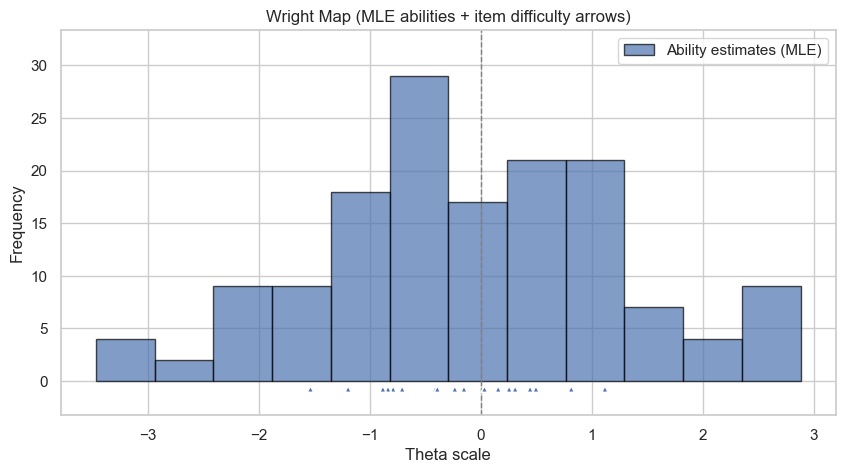

In [11]:
# Wright map using MLE abilities
plt.figure(figsize=(10, 5))
counts, bins, _ = plt.hist(theta_mle, bins=12, alpha=0.7, edgecolor='black', label='Ability estimates (MLE)')

y_arrow = -max(counts) * 0.08 if len(counts) else -1
for j, bj in enumerate(b_true):
    plt.annotate('', xy=(bj, 0), xytext=(bj, y_arrow), arrowprops=dict(arrowstyle='-|>', lw=1.2))

plt.axvline(0, color='gray', linestyle='--', lw=1)
plt.ylim(y_arrow * 1.4, max(counts) * 1.15 if len(counts) else 1)
plt.xlabel('Theta scale')
plt.ylabel('Frequency')
plt.title('Wright Map (MLE abilities + item difficulty arrows)')
plt.legend()
plt.show()

In [12]:
# MCMC sampling with a weak prior (generation density remains unknown for inference)
data_mcmc = {
    'N': N,
    'J': J,
    'y': y.tolist(),
    'b': b_true.tolist(),
    'use_prior': 1,
    'prior_sd': 5.0
}

fit_mcmc = model.sample(
    data=data_mcmc,
    seed=5101,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    show_progress=True
)

theta_draws = fit_mcmc.stan_variable('theta')  # shape: (draws, N)
theta_post_mean = theta_draws.mean(axis=0)

print(f'Draws shape: {theta_draws.shape}')
print(f'Correlation(true, posterior mean) = {np.corrcoef(theta_true, theta_post_mean)[0,1]:.3f}')

17:23:56 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

17:24:02 - cmdstanpy - INFO - CmdStan done processing.



Draws shape: (4000, 150)
Correlation(true, posterior mean) = 0.931


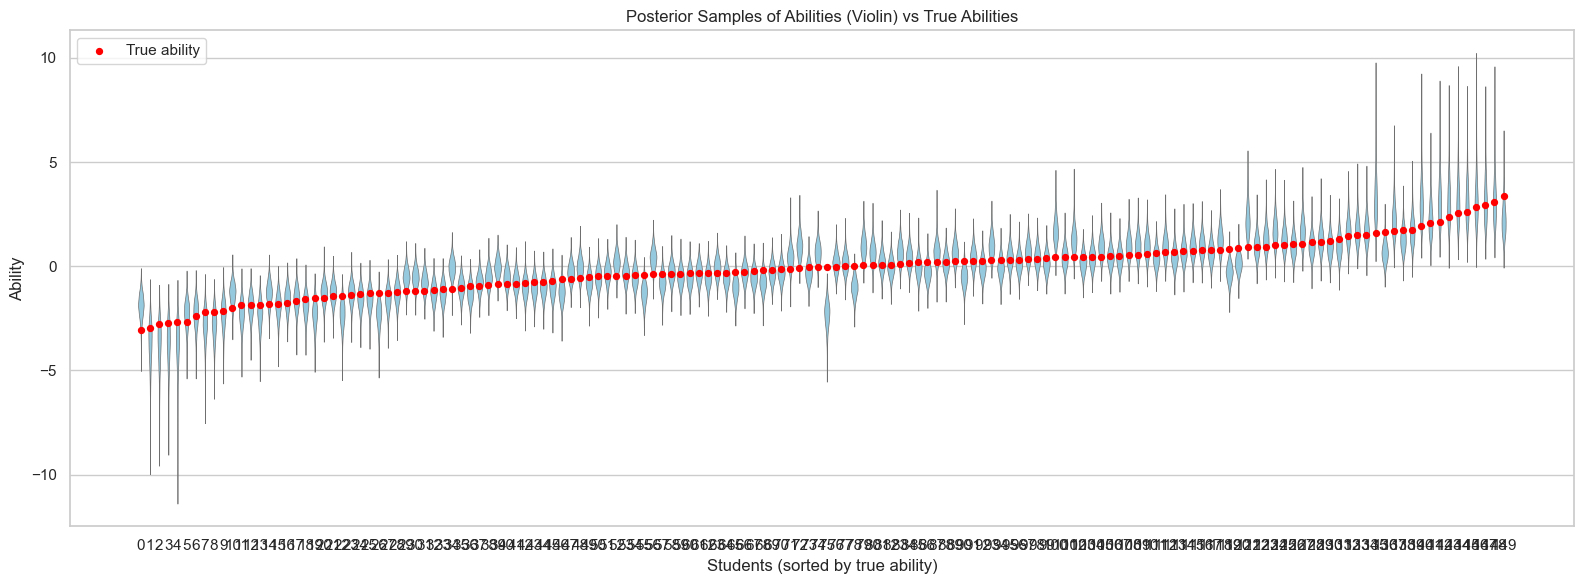

In [13]:
# Violin plots of posterior ability samples vs true abilities
order = np.argsort(theta_true)
theta_true_sorted = theta_true[order]
theta_draws_sorted = theta_draws[:, order]

df_long = pd.DataFrame(theta_draws_sorted, columns=[f'S{i+1}' for i in range(N)])
df_long = df_long.melt(var_name='student', value_name='theta_sample')

student_positions = np.arange(N)
pos_map = {f'S{i+1}': i for i in range(N)}
df_long['x'] = df_long['student'].map(pos_map)

plt.figure(figsize=(16, 6))
sns.violinplot(data=df_long, x='x', y='theta_sample', inner=None, cut=0, color='skyblue', linewidth=0.5)
plt.scatter(student_positions, theta_true_sorted, color='red', s=18, label='True ability', zorder=3)
plt.xlabel('Students (sorted by true ability)')
plt.ylabel('Ability')
plt.title('Posterior Samples of Abilities (Violin) vs True Abilities')
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
# Find students whose true ability is outside their 95% posterior interval
ci_low = np.quantile(theta_draws, 0.02, axis=0)
ci_high = np.quantile(theta_draws, 0.98, axis=0)

outside_mask = (theta_true < ci_low) | (theta_true > ci_high)
outside_idx = np.where(outside_mask)[0]

print(f'Number outside 95% posterior interval: {outside_idx.size}')

if outside_idx.size > 0:
    outside_df = pd.DataFrame({
        'student_index_1based': outside_idx + 1,
        'theta_true': theta_true[outside_idx],
        'ci_low_2%': ci_low[outside_idx],
        'ci_high_98%': ci_high[outside_idx],
    }).sort_values('student_index_1based')
    print(outside_df.to_string(index=False))
else:
    print('All true abilities are inside their 96% posterior intervals.')

Number outside 95% posterior interval: 4
 student_index_1based  theta_true  ci_low_2%  ci_high_98%
                   27    0.832984  -1.252078     0.672350
                   31   -1.098212  -1.045124     0.906576
                   53   -0.031866  -3.752476    -1.062528
                  101    0.429761   0.460038     3.346075


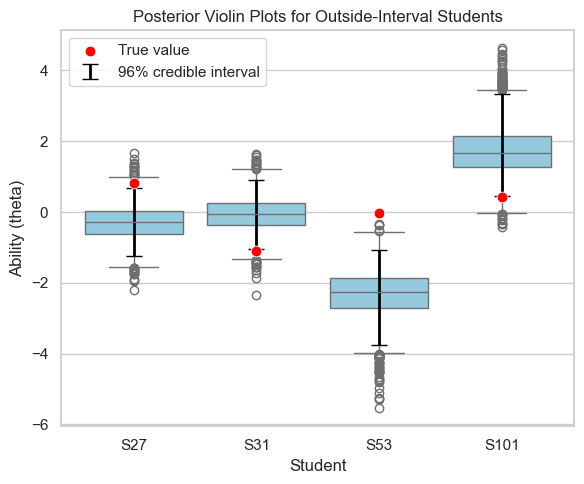

In [28]:
# Violin plots for students flagged in outside_df (with fallbacks)
if 'outside_df' in globals() and isinstance(outside_df, pd.DataFrame) and not outside_df.empty:
    if 'student_index_1based' in outside_df.columns:
        idx0 = outside_df['student_index_1based'].to_numpy(dtype=int) - 1
    else:
        raise ValueError("outside_df exists but does not contain 'student_index_1based'.")
elif 'range_outside_idx' in globals() and len(range_outside_idx) > 0:
    idx0 = np.asarray(range_outside_idx, dtype=int)
elif 'outside_idx' in globals() and len(outside_idx) > 0:
    idx0 = np.asarray(outside_idx, dtype=int)
else:
    raise ValueError("No outside student indices found (outside_df/range_outside_idx/outside_idx).")

labels = [f"S{i+1}" for i in idx0]
draws_subset = theta_draws[:, idx0]

plot_df = pd.DataFrame(draws_subset, columns=labels).melt(
    var_name='student', value_name='theta_sample'
)
true_subset = pd.DataFrame({
    'student': labels,
    'theta_true': theta_true[idx0]
})

plt.figure(figsize=(max(6, 1.2 * len(labels)), 5))
sns.boxplot(data=plot_df, x='student', y='theta_sample', color='skyblue')
sns.scatterplot(data=true_subset, x='student', y='theta_true', color='red', s=60, zorder=3, label='True value')
ci_low = np.quantile(draws_subset, 0.02, axis=0)
ci_high = np.quantile(draws_subset, 0.98, axis=0)
ci_mid = 0.5 * (ci_low + ci_high)
x_pos = np.arange(len(labels))

plt.errorbar(
    x_pos,
    ci_mid,
    yerr=[ci_mid - ci_low, ci_high - ci_mid],
    fmt='none',
    ecolor='black',
    elinewidth=2,
    capsize=6,
    label='96% credible interval',
    zorder=2
)

plt.title('Posterior Violin Plots for Outside-Interval Students')
plt.xlabel('Student')
plt.ylabel('Ability (theta)')
plt.legend()
plt.tight_layout()
plt.show()

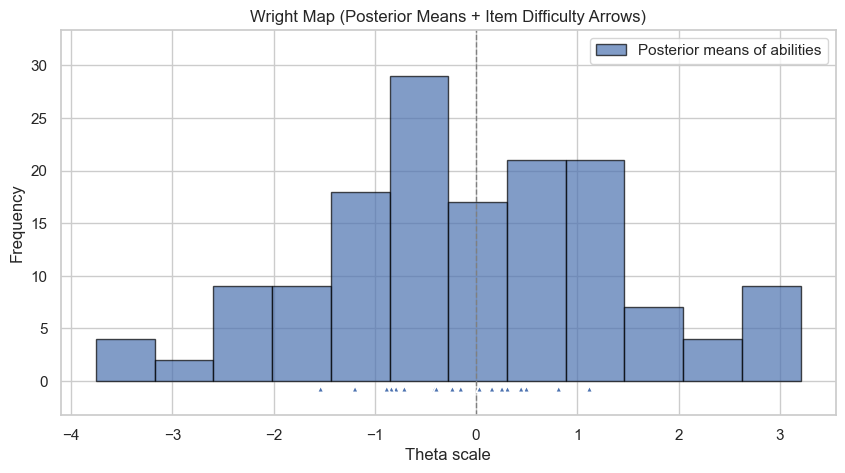

In [14]:
# Wright map using posterior means
plt.figure(figsize=(10, 5))
counts, bins, _ = plt.hist(theta_post_mean, bins=12, alpha=0.7, edgecolor='black', label='Posterior means of abilities')

y_arrow = -max(counts) * 0.08 if len(counts) else -1
for bj in b_true:
    plt.annotate('', xy=(bj, 0), xytext=(bj, y_arrow), arrowprops=dict(arrowstyle='-|>', lw=1.2))

plt.axvline(0, color='gray', linestyle='--', lw=1)
plt.ylim(y_arrow * 1.4, max(counts) * 1.15 if len(counts) else 1)
plt.xlabel('Theta scale')
plt.ylabel('Frequency')
plt.title('Wright Map (Posterior Means + Item Difficulty Arrows)')
plt.legend()
plt.show()

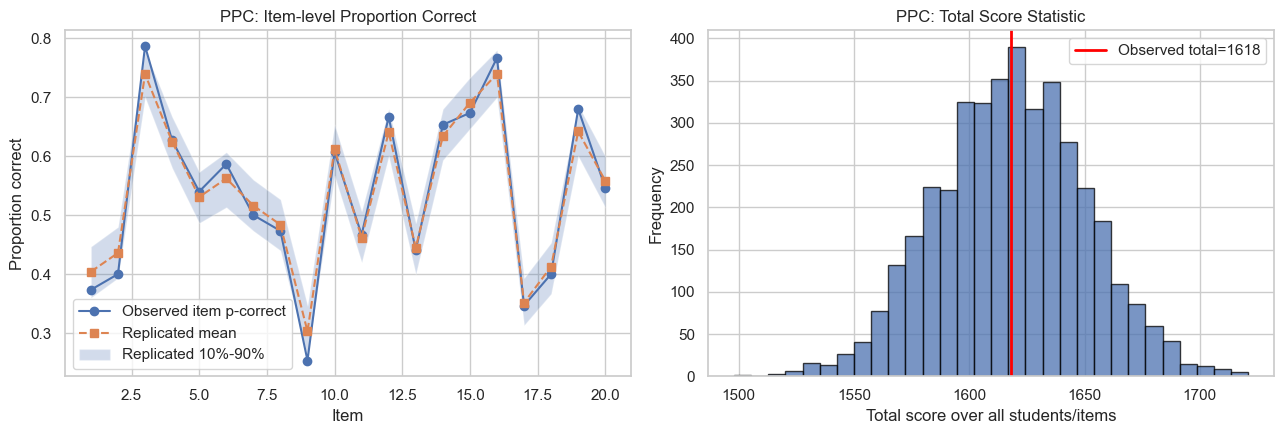

Posterior predictive p-value for total-score statistic: 0.505


In [15]:
# Posterior Predictive Check (PPC)
y_rep_draws = fit_mcmc.stan_variable('y_rep')  # shape: (draws, N, J)

obs_item_mean = y.mean(axis=0)
rep_item_mean = y_rep_draws.mean(axis=1)  # (draws, J)

obs_total = y.sum()
rep_total = y_rep_draws.sum(axis=(1, 2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(np.arange(1, J + 1), obs_item_mean, 'o-', label='Observed item p-correct')
axes[0].plot(np.arange(1, J + 1), rep_item_mean.mean(axis=0), 's--', label='Replicated mean')
axes[0].fill_between(
    np.arange(1, J + 1),
    np.quantile(rep_item_mean, 0.1, axis=0),
    np.quantile(rep_item_mean, 0.9, axis=0),
    alpha=0.25,
    label='Replicated 10%-90%'
)
axes[0].set_xlabel('Item')
axes[0].set_ylabel('Proportion correct')
axes[0].set_title('PPC: Item-level Proportion Correct')
axes[0].legend()

axes[1].hist(rep_total, bins=30, alpha=0.75, edgecolor='black')
axes[1].axvline(obs_total, color='red', lw=2, label=f'Observed total={obs_total}')
axes[1].set_xlabel('Total score over all students/items')
axes[1].set_ylabel('Frequency')
axes[1].set_title('PPC: Total Score Statistic')
axes[1].legend()

plt.tight_layout()
plt.show()

p_val = np.mean(rep_total >= obs_total)
print(f'Posterior predictive p-correct for total-score statistic: {p_val:.3f}')

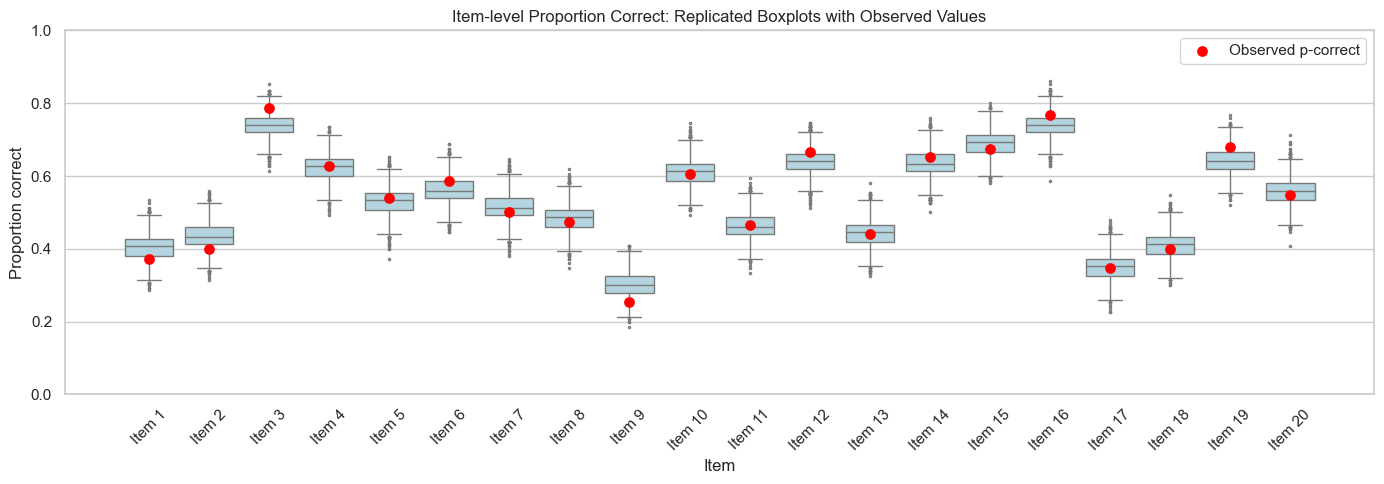

In [29]:
obs_item_mean = y.mean(axis=0)

rep_item_df = pd.DataFrame(
    rep_item_mean,
    columns=[f'Item {j+1}' for j in range(rep_item_mean.shape[1])]
).melt(var_name='item', value_name='rep_p_correct')

plt.figure(figsize=(14, 5))
sns.boxplot(data=rep_item_df, x='item', y='rep_p_correct', color='lightblue', fliersize=1.5)
plt.scatter(
    np.arange(rep_item_mean.shape[1]),
    obs_item_mean,
    color='red',
    s=45,
    zorder=3,
    label='Observed p-correct'
)

plt.xlabel('Item')
plt.ylabel('Proportion correct')
plt.title('Item-level Proportion Correct: Replicated Boxplots with Observed Values')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

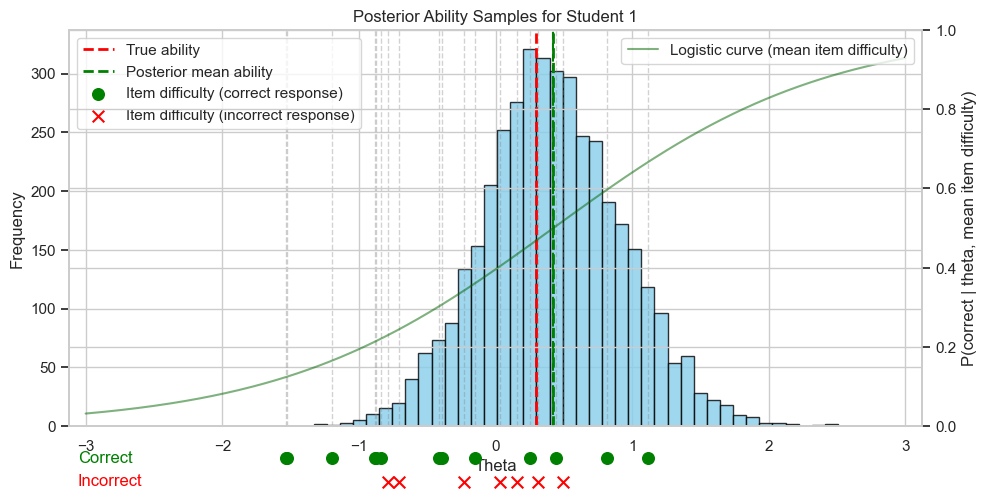

Student 1 total score: 13/20


In [39]:
student_idx = 0
theta_samples_student = theta_draws[:, student_idx]
student_responses = y[student_idx, :]

fig, ax = plt.subplots(figsize=(11, 6))

ax.hist(theta_samples_student, bins=40, color='skyblue', edgecolor='black', alpha=0.8)
ax.set_xlabel('Theta')
ax.set_ylabel('Frequency')
ax.set_title(f'Posterior Ability Samples for Student {student_idx + 1}')
ax.axvline(theta_true[student_idx], color='red', linestyle='--', lw=2, label='True ability')
ax.axvline(theta_post_mean[student_idx], color='green', linestyle='--', lw=2, label='Posterior mean ability')

theta_range = np.linspace(-3, 3, 300)
p_range = expit(theta_range - theta_post_mean[student_idx])

ax2 = ax.twinx()
ax2.plot(theta_range, expit(theta_range - theta_post_mean[student_idx]), color='darkgreen', lw=1.5, alpha=0.5, label='Logistic curve (mean item difficulty)')
ax2.axvline(theta_post_mean[student_idx], color='green', linestyle='--', lw=1.5)
ax2.set_ylabel('P(correct | theta, mean item difficulty)')
ax2.set_ylim(0, 1)
ax2.legend(loc='upper right')

for bj in b_true:
    ax.axvline(bj, color='gray', linestyle='--', alpha=0.35, linewidth=1)

correct_mask = student_responses == 1
incorrect_mask = student_responses == 0

ax.scatter(
    b_true[correct_mask],
    np.full(correct_mask.sum(), -0.08),
    transform=ax.get_xaxis_transform(),
    color='green',
    marker='o',
    s=70,
    clip_on=False,
    label='Item difficulty (correct response)'
)

ax.scatter(
    b_true[incorrect_mask],
    np.full(incorrect_mask.sum(), -0.14),
    transform=ax.get_xaxis_transform(),
    color='red',
    marker='x',
    s=70,
    clip_on=False,
    label='Item difficulty (incorrect response)'
)

ax.text(
    0.01, -0.08, 'Correct',
    transform=ax.transAxes, color='green',
    va='center', ha='left'
)
ax.text(
    0.01, -0.14, 'Incorrect',
    transform=ax.transAxes, color='red',
    va='center', ha='left'
)

ax.margins(x=0.02)
plt.subplots_adjust(bottom=0.22)
ax.legend(loc='upper left')
plt.show()

print(f"Student {student_idx + 1} total score: {student_responses.sum()}/{J}")

Student 1
Total score: 13/20
Posterior mean theta: 0.423
96% interval: [-0.610, 1.523]
Interval width: 2.133
Total test information at posterior mean: 4.050


,item,b,response,p_correct_at_post_mean,item_information
15,16,-1.535241,1,0.876379,0.108339
2,3,-1.526764,1,0.875458,0.109032
14,15,-1.195521,1,0.834637,0.138018
18,19,-0.882123,1,0.786752,0.167773
11,12,-0.871894,1,0.785031,0.168757
13,14,-0.836109,1,0.778930,0.172198
3,4,-0.789930,0,0.770876,0.176626
9,10,-0.708175,0,0.756118,0.184404
5,6,-0.410029,1,0.697066,0.211165
19,20,-0.391510,1,0.693141,0.212697


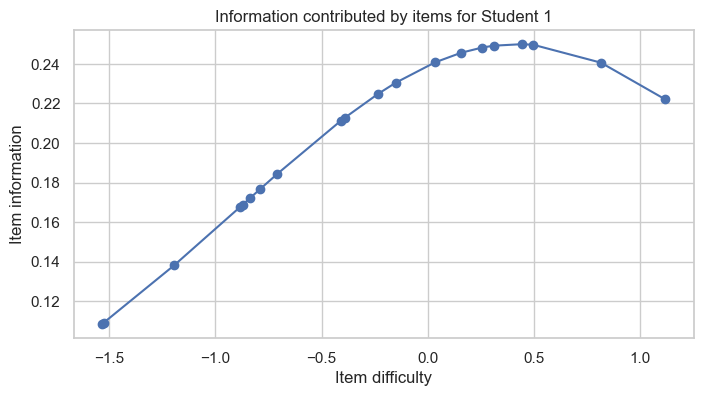

In [ ]:
i = 0

theta_ci_low = np.quantile(theta_draws[:, i], 0.02)
theta_ci_high = np.quantile(theta_draws[:, i], 0.98)
theta_ci_width = theta_ci_high - theta_ci_low

p_at_post_mean = expit(theta_post_mean[i] - b_true)
item_info = p_at_post_mean * (1 - p_at_post_mean)

student_summary = pd.DataFrame({
    'item': np.arange(1, J + 1),
    'b': b_true,
    'response': y[i],
    'p_correct_at_post_mean': p_at_post_mean,
    'item_information': item_info
}).sort_values('b')

print(f"Student {i+1}")
print(f"Total score: {y[i].sum()}/{J}")
print(f"Posterior mean theta: {theta_post_mean[i]:.3f}")
print(f"96% interval: [{theta_ci_low:.3f}, {theta_ci_high:.3f}]")
print(f"Interval width: {theta_ci_width:.3f}")
print(f"Total test information at posterior mean: {item_info.sum():.3f}")

display(student_summary)

plt.figure(figsize=(8, 4))
plt.plot(student_summary['b'], student_summary['item_information'], marker='o')
plt.xlabel('Item difficulty')
plt.ylabel('Item information')
plt.title(f'Information contributed by items for Student {i+1}')
plt.show()

### Wide Credible Interval for Student 1

A width around 2.13 for Student 1 is not especially surprising in this notebook. 
- The main reason is that the posterior is being learned from only 20 binary responses, and binary data are intrinsically noisy. 
- For Student 1, the score is 13 out of 20, with posterior mean about 0.423 and a 2% to 98% interval of about [-0.610, 1.523]. 
- That is a moderate score, not an extreme one, so it identifies ability only roughly rather than sharply.

- The more direct explanation is information. 
- In the diagnostic summary from the logic in IRT_D1_Rasch_1PL_KnownItem.ipynb, the total test information for Student 1 at the posterior mean is about 4.05. 
- In a Rasch model, posterior/likelihood curvature is roughly driven by total information, so the local standard error is about $1 / \sqrt{4.05} \approx 0.50$. 
- A central interval is then expected to be on the order of 4 standard errors wide, which gives about $2.0$, very close to what you saw. 
- So the interval is wide mainly because 20 items only give moderate precision here.

#### A few concrete reasons in this run:

1. The test is short. With only 20 items, even a well-targeted Rasch test cannot produce a very tight interval for each student.
2. Each item contributes at most 0.25 information, and Student 1’s total is about 4.05, which is moderate rather than high.
3. The prior is weak in the sampling model, as defined in IRT_D1_Rasch_1PL_KnownItem.ipynb and used in IRT_D1_Rasch_1PL_KnownItem.ipynb, so it does not shrink the posterior much.
4. Several items are not perfectly targeted to this student. The item information plot peaks around difficulties near the student’s estimated ability, but items far below or above that point contribute less.
5. The interval you are calling 95% is actually a 2% to 98% interval in IRT_D1_Rasch_1PL_KnownItem.ipynb, so it is a 96% interval and is slightly wider than a usual 95% interval.

So the result is more a sign of limited measurement precision than a problem with the sampler. If you want narrower intervals, the main levers are straightforward: 
- add more items, 
- target more items near each student’s ability level, 
- or use a stronger prior if that is substantively justified.

